In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data hasil preprocessing (Tahap 2)
# Pastikan file ini ada di folder Colab Anda
try:
    df = pd.read_csv('dataset_bersih_iphone17.csv')
    print(f"Data berhasil dimuat! Jumlah data: {len(df)}")
except FileNotFoundError:
    print("Error: File 'dataset_siap_labeling.csv' tidak ditemukan. Upload dulu atau jalankan Tahap 2.")

# --- DOWNLOAD LEXICON INDONESIA ---
# Kita gunakan URL raw dari GitHub untuk kamus positif & negatif
url_pos = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
url_neg = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

# Load Lexicon ke DataFrame
lexicon_pos = pd.read_csv(url_pos, sep='\t')
lexicon_neg = pd.read_csv(url_neg, sep='\t')

# Ubah ke dalam bentuk Set agar pencarian lebih cepat
# Kita ambil kolom katanya saja
set_pos = set(lexicon_pos['word'])
set_neg = set(lexicon_neg['word'])

print(f"Jumlah kata positif di kamus: {len(set_pos)}")
print(f"Jumlah kata negatif di kamus: {len(set_neg)}")

Data berhasil dimuat! Jumlah data: 1069
Jumlah kata positif di kamus: 3609
Jumlah kata negatif di kamus: 6607


In [ ]:
# --- UPDATE KODE TAHAP 3 (Labeling) ---

# 1. Definisikan Kata Penyangkal (Negasi)
list_negasi = ['tidak', 'enggak', 'gak', 'bukan', 'jangan', 'kurang']
set_negasi = set(list_negasi)

def tentukan_sentimen_pintar(text):
    score = 0
    words = str(text).split()

    # Loop melalui setiap kata
    for i, word in enumerate(words):
        word_score = 0

        # Cek apakah kata ada di kamus positif/negatif
        if word in set_pos:
            word_score = 1
        elif word in set_neg:
            word_score = -3

        # --- LOGIKA NEGASI (PENTING) ---
        # Cek kata sebelumnya (index i-1). Jika kata sebelumnya adalah "tidak/enggak",
        # maka nilai kata saat ini dikali -1 (dibalik).
        if i > 0 and words[i-1] in set_negasi:
            word_score = word_score * -1

        score += word_score

    # Klasifikasi
    if score > 0:
        return 'Positif'
    elif score < 0:
        return 'Negatif'
    else:
        return 'Netral'

# Terapkan fungsi baru
print("Mengulang labeling dengan logika Negasi...")
df['label_otomatis'] = df['text_stemmed'].apply(tentukan_sentimen_pintar)

# Cek hasilnya lagi untuk kalimat yang ada "enggak"
cek_ulang = df[df['text_stemmed'].str.contains('enggak', na=False)]
print(cek_ulang[['text_stemmed', 'label_otomatis']].head(10))

Mengulang labeling dengan logika Negasi...
                                         text_stemmed label_otomatis
3   pakai ada dulu mau beli sayang duit malah jatu...        Positif
18  raw handphone aku xiaomi enggak paham buat apa...        Positif
20             centre stage kamera depan enggak bahas        Negatif
33  fitur gimmick orang gila mana beli handphone m...        Negatif
39  iphone bawa vivo kali oppo find kali iphone se...        Negatif
42  mobile kontent kreator cuman up medosos kasi h...        Positif
43  enggak butuh pixel tinggi enggak butuh codec b...        Positif
47  game makin keren handphone makin canggih sayan...         Netral
60  iphone pro warna orange terinvirasi warna pabr...        Negatif
68  ku iphone bagus kamera jernihzoom bagus pas ka...        Positif


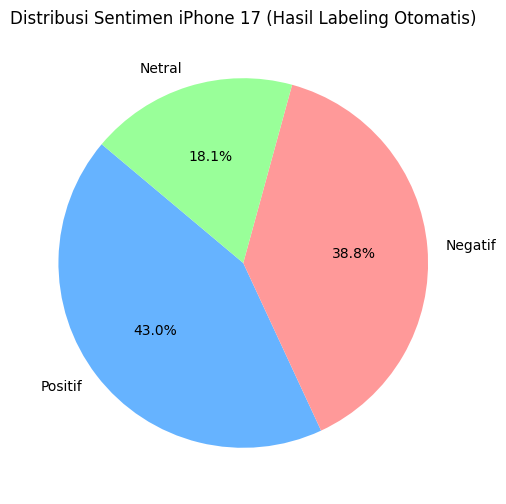

/tmp/ipython-input-1114594968.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label_otomatis', data=df, palette='viridis')


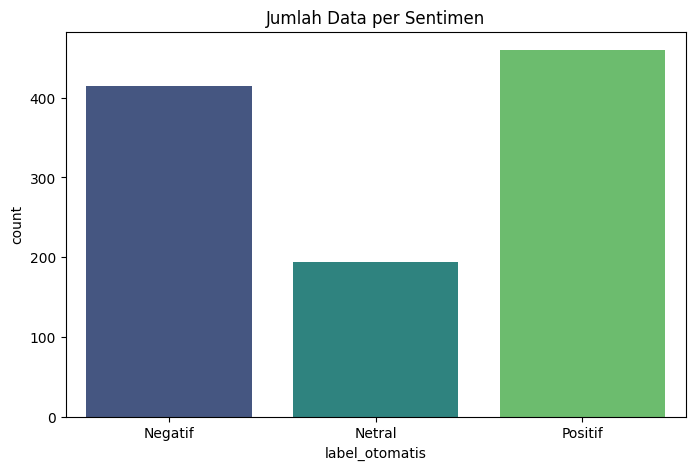

label_otomatis
Positif    460
Negatif    415
Netral     194
Name: count, dtype: int64


In [ ]:
# Hitung jumlah setiap label
sentiment_counts = df['label_otomatis'].value_counts()

# Buat Visualisasi Pie Chart
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999','#99ff99'])
plt.title('Distribusi Sentimen iPhone 17 (Hasil Labeling Otomatis)')
plt.show()

# Buat Bar Chart
plt.figure(figsize=(8,5))
sns.countplot(x='label_otomatis', data=df, palette='viridis')
plt.title('Jumlah Data per Sentimen')
plt.show()

print(sentiment_counts)

In [ ]:
# Simpan hasil labeling
filename_labeled = "dataset_labeled.csv"
df.to_csv(filename_labeled, index=False)

print(f"Sukses! Data berlabel tersimpan di {filename_labeled}.")

Sukses! Data berlabel tersimpan di dataset_labeled.csv.
